# AlexNet 실습

## AlexNet 모델을 구현한 후 MNIST 데이터셋 분류 실습

### 1. 데이터셋 불러오기
- torchvision에 있는 MNIST 데이터셋을 이용
- 기존 AlexNet은 227*227 입력을 사용했지만 MNIST 데이터셋에 비해 계산량이 과도하게 커지므로 28*28 이미지를 64*64로 ReSize하여 사용

### 2. 모델 생성
- AlexNet의 기본 구조를 참고하여 5개의 Conv층과 3개의 max_pool 계층, 3개의 Fully Connected 계층으로 구성
- 활성화 함수로는 ReLU 사용
- 기존 AlexNet의 출력 채널 수(96, 256, 384, 384, 256)는 MNIST 데이터셋에 맞게 (32, 64, 128, 128, 64)로 축소

### 3. 학습 설정
- 최적화 알고리즘으로 Adam을 사용하고, 하이퍼파라미터인 학습률(lr)을 1e-3로 설정
- 손실함수로는 분류 문제에 사용되는 Cross Entropy Loss 사용

### 4. 훈련
- LeNet보다 더 깊고 복잡한 구조이므로 학습 시간을 고려해 epoch를 10으로 설정하여 모델 학습을 진행
- 각 epoch 마다 training loss를 저장하고 계산하여 학습 경향을 확인

### 5. 모델 평가
- 학습이 끝난 후 model.eval()을 사용하여 평가 모드로 변경
- torch.no_grad()를 사용해 gradient 계산을 비활성화한 뒤, test_loader를 이용해 테스트 정확도를 계산
- 예측 클래스와 실제 정답을 비교해 전체 정확도 측정

### 6. 시각화
- epoch에 따른 training loss를 그래프로 시각화하여 학습이 안정적으로 진행되는지 확인

In [2]:
#AlexNet 모델을 이용하여 MNIST 데이터셋 훈련

#1. 데이터셋 불러오기
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 이미지 패딩을 위한 변 환 추가
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

In [3]:
#2. AlexNet 모델 생성

# 기존의 AlexNet 구조를 수정 처음 conv층의 feature_out 값을 96 -> 32로

import torch
import torch.nn as nn
import torch.nn.functional as F

class AlexNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 32, 11, 4, padding=2)
    self.conv2 = nn.Conv2d(32, 64, 5, padding=2)
    self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
    self.conv4 = nn.Conv2d(128, 128, 3, padding=1)
    self.conv5 = nn.Conv2d(128, 64, 3, padding=1)

    self.fc1 = nn.Linear(64, 512)
    self.fc2 = nn.Linear(512, 256)
    self.fc3 = nn.Linear(256, 10) # MNIST는 10개 클래스이므로 10으로 변경

  def forward(self, x):
    x = F.relu(F.max_pool2d(self.conv1(x), kernel_size=3, stride=2))
    x = F.relu(F.max_pool2d(self.conv2(x), kernel_size=3, stride=2))
    x = F.relu(self.conv3(x))
    x = F.relu(self.conv4(x))
    x = F.relu(F.max_pool2d(self.conv5(x), kernel_size=3, stride=2))

    x = torch.flatten(x, 1)
    x = F.dropout(F.relu(self.fc1(x)), p=0.5, training=self.training)
    x = F.dropout(F.relu(self.fc2(x)), p=0.5, training=self.training)
    x = self.fc3(x)

    return x

In [4]:
#3. 학습 설정
dev_name = 'cuda' if torch.cuda.is_available() else 'cpu'
device = torch.device(dev_name)

model = AlexNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [5]:
#4. 훈련
def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
  train_losses = []

  for epoch in range(n_epochs):
    model.train()
    loss_train = 0.0

    for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)

      output = model(images)
      loss = loss_fn(output, labels)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      loss_train += loss.item()

    avg_train_loss = loss_train / len(train_loader)
    train_losses.append(avg_train_loss)

    if epoch == 0 or epoch % 2 == 0:
      print(f'Epoch {epoch}, Training loss {loss_train/len(train_loader)}')

  return train_losses


train_losses = training_loop(n_epochs=10, optimizer=optimizer, model=model, loss_fn=criterion, train_loader=train_loader)

Epoch 0, Training loss 0.38622257475930577
Epoch 2, Training loss 0.06967646142024217
Epoch 4, Training loss 0.0539220139830164
Epoch 6, Training loss 0.04712377782847689
Epoch 8, Training loss 0.04142253197878612


In [9]:
# 5. 모델 평가
def evalute_accuracy(model, data_loader):
  model.eval()
  correct = 0
  total = 0

  with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(device=dev_name), labels.to(device=dev_name)
          outputs = model(images)
          _, predicted = torch.max(outputs, 1) # 가장 높은 확률을 가진 클래스 선택
          total += labels.size(0) # 전체 샘플 수 업데이트
          correct += (predicted == labels).sum().item() # 올바르게 예측된 샘플 수 업데이트

  accuracy = 100 * correct / total
  return accuracy

  print(f'Test Accuracy: {accuracy:.2f}%')

test_accuracy = evalute_accuracy(model, test_loader)

print(test_accuracy)

98.46


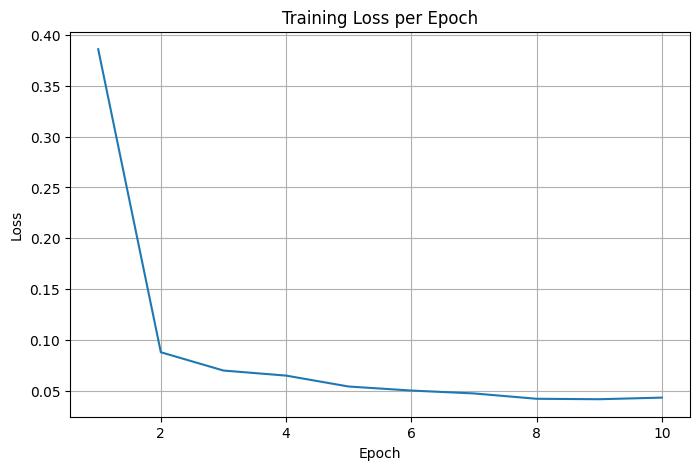

In [7]:
# 훈련 손실 및 정확도 판단
import matplotlib.pyplot as plt

# 훈련 손실 그래프
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses)
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# 테스트 정확도 그래프

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
